# Лабораторная 3
## Исследование Устойчивого распределения

### 1. Определение случайных величин. Плотность распределения, функция распределения и характеристическая функция.

Случайная величина $X$ имеет устойчивое распределение, если: $$X \sim S_\alpha(\sigma, \beta, \mu)$$
где $0 < \alpha \le 2,\ \sigma>0,\ -1 \le \beta \le 1,\ \mu \in \mathbb{R}$


Подключение нужных библиотек.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import levy_stable

ALPHA: float = 1.5
MU: float = 0
SIGMA: float = 1
BETA: float = 0

ALPHA_ARR = [0.5, 1, 1.5, 2]
MU_ARR = [-2, 0, 2]
SIGMA_ARR = [0.5, 1, 2]
BETA_ARR = [-1, -0.5, 0, 0.5, 1]

### 2. Графики плотности и функции распределения.

Зафиксируем $\sigma=1, \nu=0, \beta=0$ и рассмотрим три значения $\alpha = 0.5, 1, 2$. Построим плотности и функции распределения:

In [25]:
x = np.linspace(-7, 7, 1000)

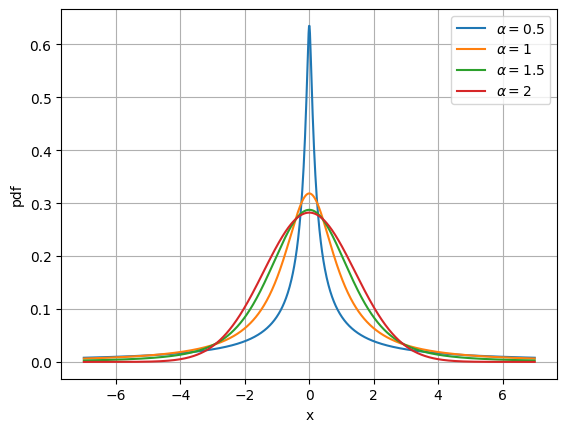

In [26]:
for alpha in ALPHA_ARR:
    pdf = levy_stable.pdf(x, alpha, BETA, MU, SIGMA)
    plt.plot(x, pdf, label=rf"$\alpha=${alpha}")
plt.xlabel("x")
plt.ylabel("pdf")
plt.grid()
plt.legend()
plt.show()

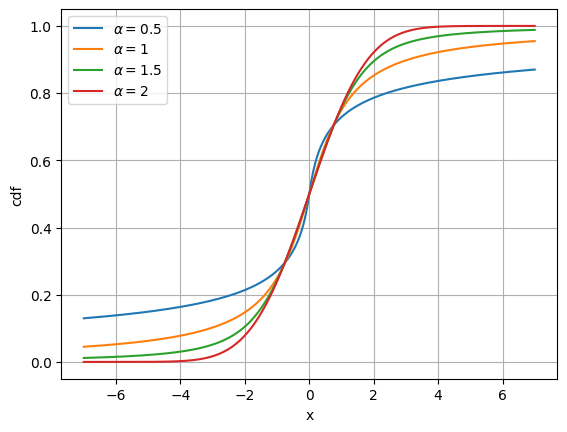

In [27]:
for alpha in ALPHA_ARR:
    сdf = levy_stable.cdf(x, alpha, BETA, MU, SIGMA)
    plt.plot(x, сdf, label=rf"$\alpha=${alpha}")
plt.xlabel("x")
plt.ylabel("cdf")
plt.grid()
plt.legend()
plt.show()

Вывод: 
1. Плотность: с ростом $\alpha$ увеличивается пик графика, хвосты становятся легче.
2. Функция распределения: с увеличением $\alpha$ ускоряется рост графика, но он начинается позже.

При $\alpha=2$ устойчивое распределение совпадает с нормальным гауссовским.

Зафиксируем $\sigma=1, \beta=0, \alpha=2$ и рассмотрим три значения $\mu = -2, 0, 2$. Построим плотности и функции распределения:

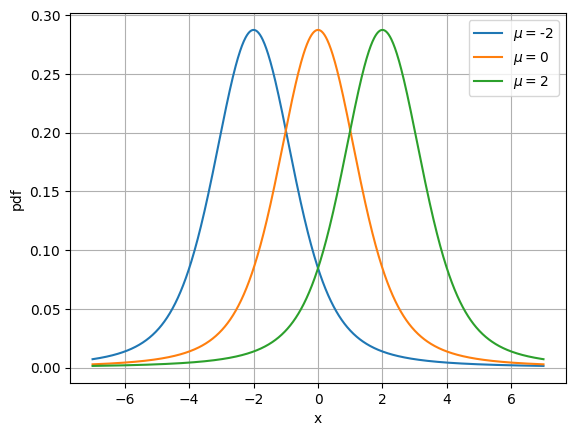

In [28]:
for mu in MU_ARR:
    pdf = levy_stable.pdf(x, ALPHA, BETA, mu, SIGMA)
    plt.plot(x, pdf, label=rf"$\mu=${mu}")
plt.xlabel("x")
plt.ylabel("pdf")
plt.grid()
plt.legend()
plt.show()

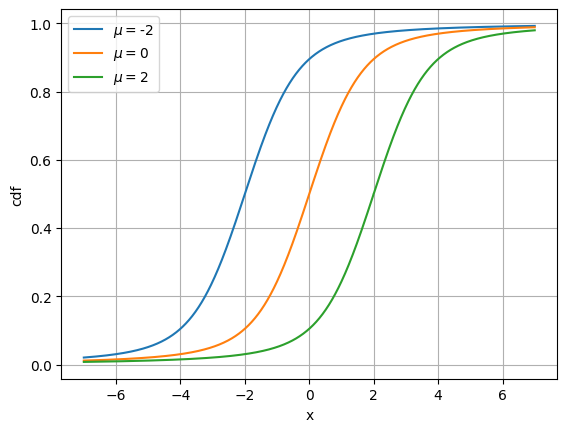

In [29]:
for mu in MU_ARR:
    cdf = levy_stable.cdf(x, ALPHA, BETA, mu, SIGMA)
    plt.plot(x, cdf, label=rf"$\mu=${mu}")
plt.xlabel("x")
plt.ylabel("cdf")
plt.grid()
plt.legend()
plt.show()

Вывод: 
1. Плотность: график смещается вдоль оси $x$.
2. Функция распределения: также смещается вдоль оси $x$.

Зафиксируем $\mu=0, \beta=0, \alpha=2$ и рассмотрим три значения $\sigma = 0.5, 1, 2$. Построим плотности и функции распределения:

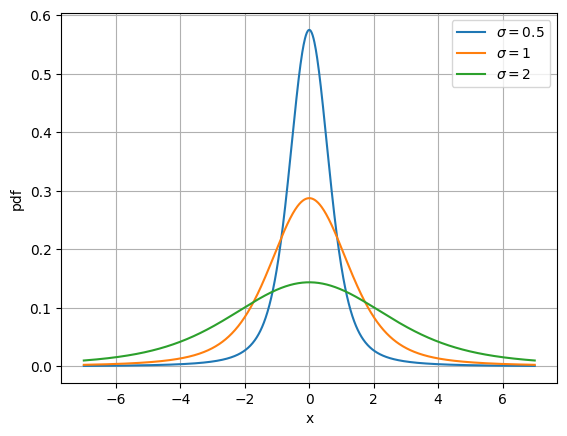

In [30]:
for sigma in SIGMA_ARR:
    pdf = levy_stable.pdf(x, ALPHA, BETA, MU, sigma)
    plt.plot(x, pdf, label=rf"$\sigma=${sigma}")
plt.xlabel("x")
plt.ylabel("pdf")
plt.grid()
plt.legend()
plt.show()

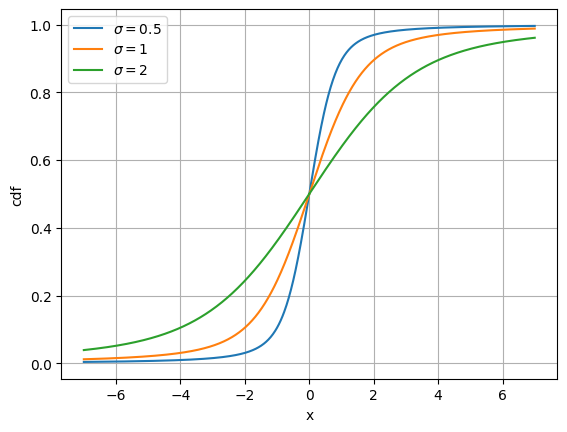

In [31]:
for sigma in SIGMA_ARR:
    cdf = levy_stable.cdf(x, ALPHA, BETA, MU, sigma)
    plt.plot(x, cdf, label=rf"$\sigma=${sigma}")
plt.xlabel("x")
plt.ylabel("cdf")
plt.grid()
plt.legend()
plt.show()

Вывод: 
1. Плотность: параметр $\sigma$ сжимает или растягивает распределение вокруг $\mu$.
2. Функция распределения: с ростом $\sigma$ график начинает расти более плавно.

Зафиксируем $\sigma=1, \mu=0, \nu=1$ и рассмотрим три значения $\theta = 0, 1, 2$. Построим плотности и функции распределения:

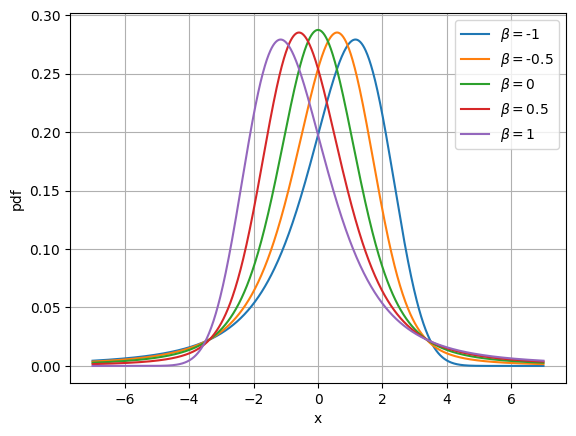

In [32]:
for beta in BETA_ARR:
    pdf = levy_stable.pdf(x, ALPHA, beta, MU, SIGMA)
    plt.plot(x, pdf, label=rf"$\beta=${beta}")
plt.xlabel("x")
plt.ylabel("pdf")
plt.grid()
plt.legend()
plt.show()

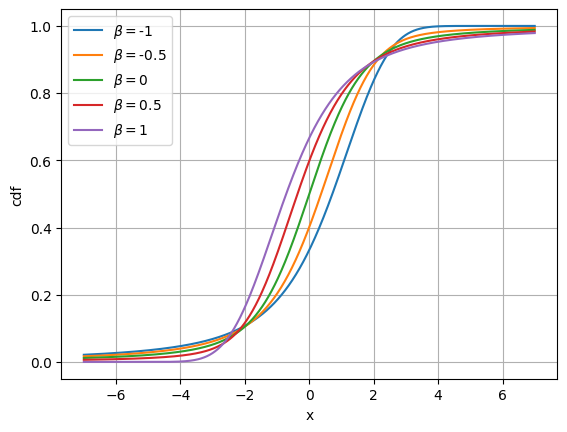

In [33]:
for beta in BETA_ARR:
    cdf = levy_stable.cdf(x, ALPHA, beta, MU, SIGMA)
    plt.plot(x, cdf, label=rf"$\beta=${beta}")
plt.xlabel("x")
plt.ylabel("cdf")
plt.grid()
plt.legend()
plt.show()

Вывод: 
1. Плотность: $\beta$ означает перекос распределения. При отрицательном $\beta$ распределение скошено влево, при положительном - вправо.
2. Функция распределения: скос графика плотности ожидаемо влияет на график функции распределения: перемещается пик скорости функции распределения влево при отрицательном $\beta$ и вправо при положительном.

## 3. Моделирование случайной выборки. Точность моделирования (критерии). Алгоритм моделирования.

Алгоритм:
1. Генерируется случайное время из гамма-распределения $g$.
2. Подставляется в условное нормальное распределение: $\text{VG} = \theta \cdot g + \sigma \cdot \sqrt{g} \cdot \mathcal{N}(0,1)$.

Для проверки гипотезы $H_0$: сгенерированная выборка соответствует устойчивому распределению с параметрами $\alpha, \mu, \sigma, \beta$ используются статистический критерий Колмогорова-Смирнова с уровнем значимости $\alpha=0.95$.

In [34]:
sample = levy_stable.rvs(ALPHA, BETA, MU, SIGMA, size=1000)

ks_stat, ks_p_value = stats.kstest(sample, lambda x: levy_stable.cdf(x, ALPHA, BETA, MU, SIGMA))
print(f"Kolmogorov-Smirnov test: statistic={ks_stat}, p-value={ks_p_value}")

Kolmogorov-Smirnov test: statistic=0.029000000000000026, p-value=0.3626924265929421


## 4. Оценка параметров распределения. Точность оценивания (критерии).

Параметрами распределения являются $\mu, \theta, \alpha, \beta$, находятся их оценки методом максимального правдоподобия.

In [35]:
moments = levy_stable.fit(sample)
print(rf"$\mu$ = {moments[2]}, $\alpha$ = {moments[0]}, $\sigma$ = {moments[3]}, $\beta$ = {moments[1]}, ")

$\mu$ = 0.004686138692695935, $\alpha$ = 1.5099366174523763, $\sigma$ = 0.9508417557183766, $\beta$ = -0.07475131678910221, 


## 5. Оценка плотности распределения

Для оценки плотности распределения используется ядерная оценка с гауссовским ядром.

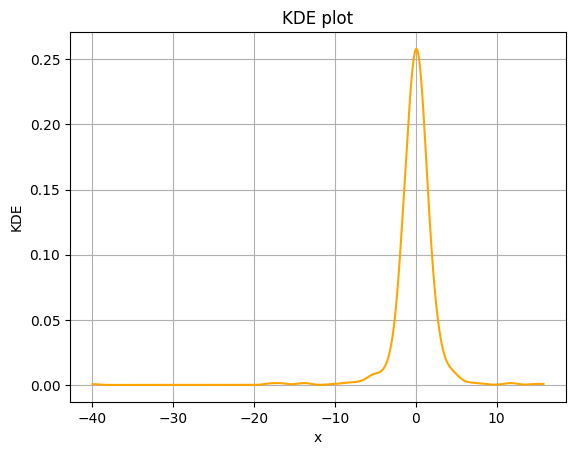

In [ ]:
kde = stats.gaussian_kde(sample)
density = kde(x)

plt.plot(x, density, color="orange")
plt.xlabel("x")
plt.ylabel("KDE")
plt.title("KDE plot")
plt.grid()
plt.show()

## 6. На одном графике: плотность распределения, гистограмма и оценка плотности распределения

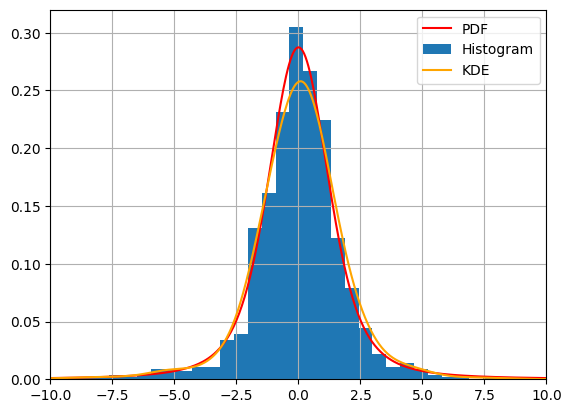

In [96]:
pdf = levy_stable.pdf(x, ALPHA, BETA, MU, SIGMA)

plt.plot(x, pdf, color="red", label="PDF")
plt.hist(sample, bins=100, density=True, label="Histogram")
plt.plot(x, density, color="orange", label="KDE")

plt.xlim(-10, 10)
plt.grid()
plt.legend()
plt.show()

## 7. Исследовать квантиль распределения в зависимости от параметров распределения. Вычислить VaR.

Зафиксируем $\alpha=1, \sigma=1, \beta=0$. Построим график зависимости квантиля распределения от $\mu$. Возьмём $p=0.95$

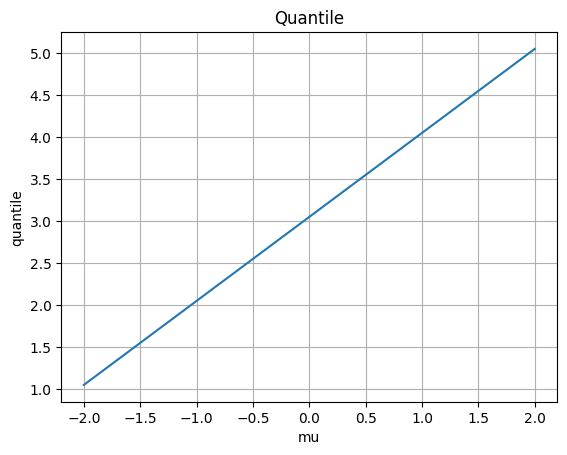

In [38]:
p = 0.95
mu_values = np.linspace(-2, 2, 100)
quantiles: list[float] = []
for mu in mu_values:
    quantiles.append(levy_stable.ppf(p, ALPHA, BETA, mu, SIGMA))
plt.plot(mu_values, quantiles)
plt.xlabel("mu")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \sigma=1, \beta=0$. Построим график зависимости квантиля распределения от $\alpha$. Возьмём $p=0.95$

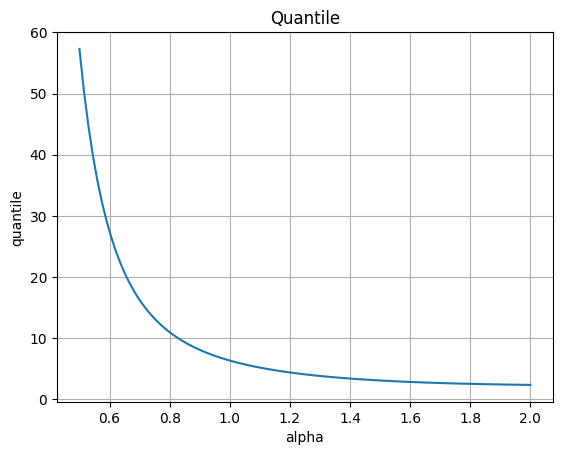

In [39]:
p = 0.95
alpha_values = np.linspace(0.5, 2, 100)
quantiles: list[float] = []
for alpha in alpha_values:
    quantiles.append(levy_stable.ppf(p, alpha, BETA, MU, SIGMA))
plt.plot(alpha_values, quantiles)
plt.xlabel("alpha")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \alpha=1, \beta=1$. Построим график зависимости квантиля распределения от $\sigma$. Возьмём $p=0.95$

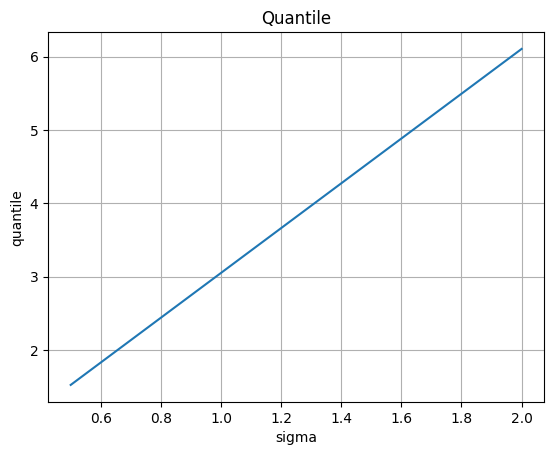

In [40]:
p = 0.95
sigma_values = np.linspace(0.5, 2, 70)
quantiles: list[float] = []
for sigma in sigma_values:
    quantiles.append(levy_stable.ppf(p, ALPHA, BETA, MU, sigma))
plt.plot(sigma_values, quantiles)
plt.xlabel("sigma")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0, \sigma=1, \alpha=1$. Построим график зависимости квантиля распределения от $\beta$. Возьмём $p=0.95$

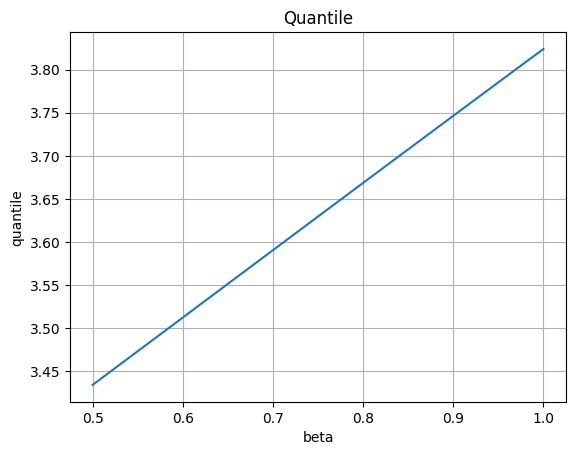

In [41]:
p = 0.95
beta_values = np.linspace(0.5, 2, 70)
quantiles: list[float] = []
for beta in beta_values:
    quantiles.append(levy_stable.ppf(p, ALPHA, beta, MU, SIGMA))
plt.plot(beta_values, quantiles)
plt.xlabel("beta")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Вычислим VaR:

In [42]:
p = 0.95

var = levy_stable.ppf(p, ALPHA, BETA, MU, SIGMA)
print(f"  VaR_{p*100:.0f}% = {var:.4f}")

  VaR_95% = 3.0519
